In [1]:
## Part 1: CNN — Shoe Classification | Part 2: RNN (LSTM) — Tweet Sentiment

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, shutil

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

# PART 1 — CNN: Shoe Classification

In [5]:
train_path = "/content/drive/MyDrive/DL Exam/CNN/Shoe Classification/train"
test_path  = "/content/drive/MyDrive/DL Exam/CNN/Shoe Classification/test"
print(os.listdir(train_path))

['Slippers', 'Sandals', 'Boots']


In [6]:
new_folder = os.path.join(test_path, "all")
os.makedirs(new_folder, exist_ok=True)

for file in os.listdir(test_path):
    file_path = os.path.join(test_path, file)
    if file.endswith(('.jpg', '.png', '.jpeg')):
        shutil.move(file_path, new_folder)

print("Test folder ready:", os.listdir(test_path))

Test folder ready: ['all']


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [8]:
train_data = train_datagen.flow_from_directory(
    train_path, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_path, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_path, target_size=(224,224), batch_size=32,
    class_mode=None, shuffle=False
)

print("Class indices:", train_data.class_indices)

Found 623 images belonging to 3 classes.
Found 155 images belonging to 3 classes.
Found 89 images belonging to 1 classes.
Class indices: {'Boots': 0, 'Sandals': 1, 'Slippers': 2}


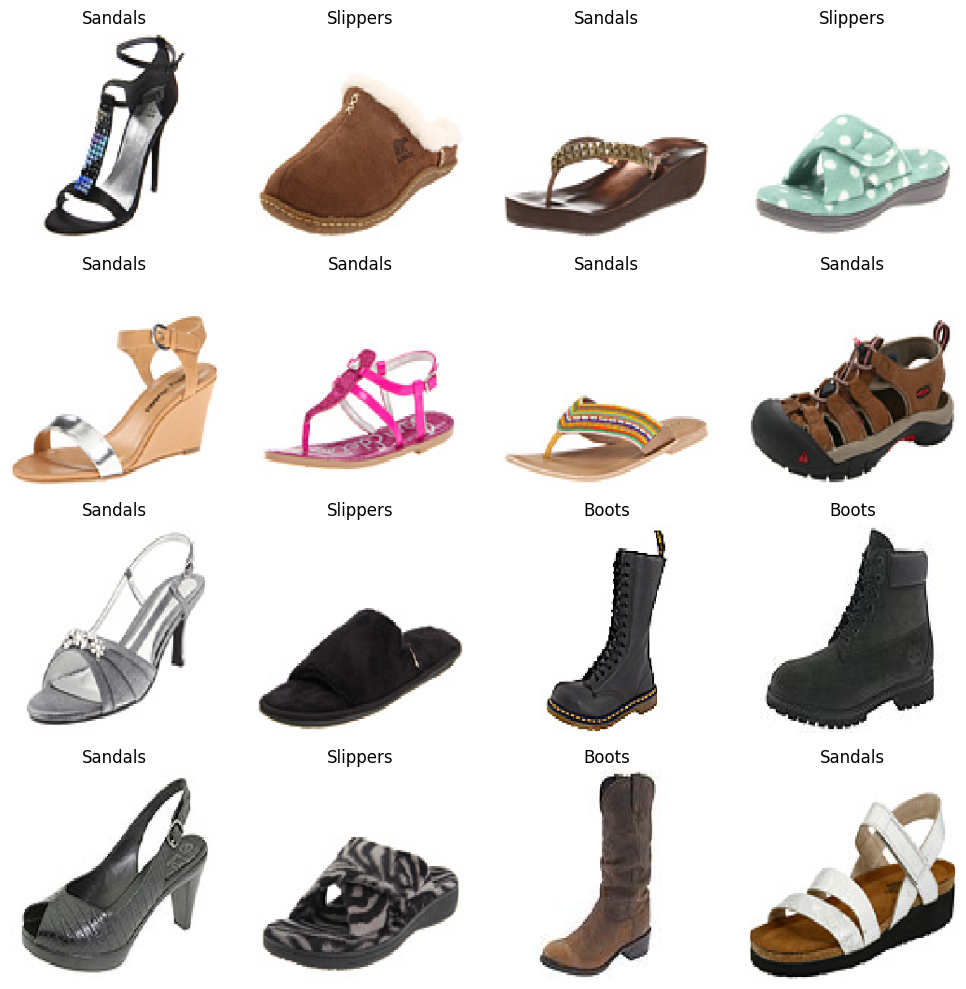

In [9]:
# FIX: class_names was undefined in original — now derived from train_data

class_names = list(train_data.class_indices.keys())
label_map   = {i: name for i, name in enumerate(class_names)}

batch = next(train_data)
images, labels = batch

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow((images[i] * 255).astype('uint8'))
        ax.set_title(label_map[np.argmax(labels[i])])
        ax.axis('off')
    else:
        ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')  # dynamic — adapts to number of classes
])
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Run fit() again with the callback
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 529ms/step - accuracy: 0.6276 - loss: 1.0644 - val_accuracy: 0.8710 - val_loss: 0.3752
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.8523 - loss: 0.3381 - val_accuracy: 0.9355 - val_loss: 0.2517
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.8876 - loss: 0.2859 - val_accuracy: 0.9226 - val_loss: 0.2853
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.9406 - loss: 0.1673 - val_accuracy: 0.9290 - val_loss: 0.3371
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.9502 - loss: 0.1326 - val_accuracy: 0.8516 - val_loss: 0.3275


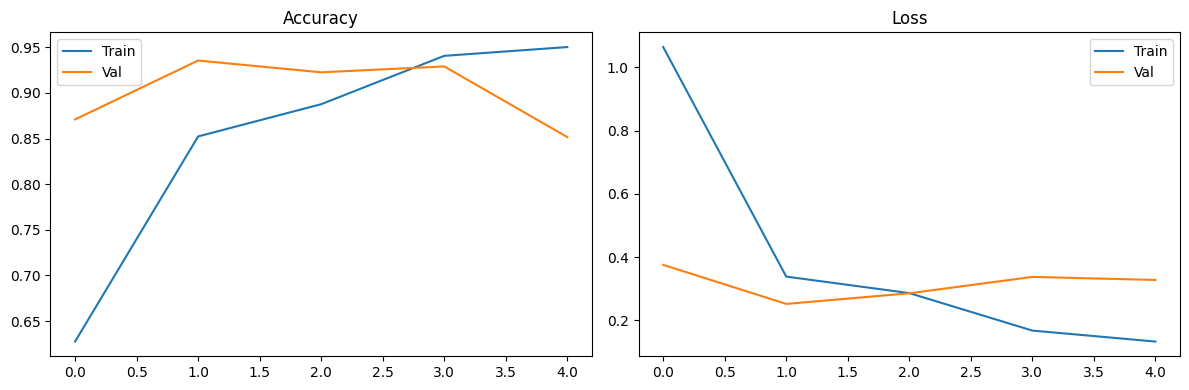

In [13]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train'); axes[0].plot(history.history['val_accuracy'], label='Val'); axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'],         label='Train'); axes[1].plot(history.history['val_loss'],     label='Val'); axes[1].set_title('Loss');     axes[1].legend()
plt.tight_layout(); plt.show()

In [14]:
# Batch predictions on all test images
predictions       = cnn_model.predict(test_data)
predicted_classes = predictions.argmax(axis=1)

class_labels      = {v: k for k, v in train_data.class_indices.items()}
final_predictions = [class_labels[i] for i in predicted_classes]

results = pd.DataFrame({'Image': test_data.filenames, 'Predicted_Class': final_predictions})
print(results['Predicted_Class'].value_counts())
results.head(10)

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step
Predicted_Class
Boots       31
Slippers    30
Sandals     28
Name: count, dtype: int64


,Image,Predicted_Class
0,all/image (1).jpg,Sandals
1,all/image (10).jpg,Boots
2,all/image (11).jpg,Boots
3,all/image (12).jpg,Slippers
4,all/image (13).jpg,Boots
5,all/image (14).jpg,Sandals
6,all/image (15).jpg,Boots
7,all/image (16).jpg,Sandals
8,all/image (17).jpg,Sandals
9,all/image (18).jpg,Boots


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step


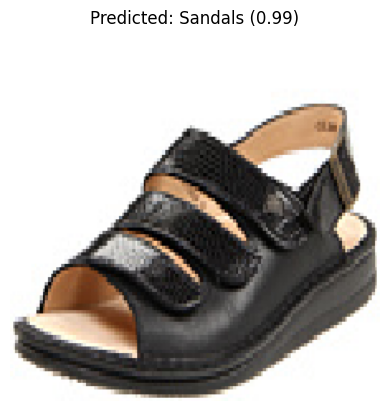

In [15]:
# Single image prediction
test_data.reset()
images_batch = next(test_data)
img          = images_batch[0]
img_input    = np.expand_dims(img, axis=0)

pred       = cnn_model.predict(img_input)
pred_class = np.argmax(pred)
confidence = np.max(pred)

plt.imshow(img); plt.axis('off')
plt.title(f"Predicted: {class_labels[pred_class]} ({confidence:.2f})")
plt.show()

In [16]:
# PART 2 — RNN (LSTM): Tweet Sentiment Analysis

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import models, layers

In [18]:
train = pd.read_csv("/content/drive/MyDrive/DL Exam/RNN/tweets_train.csv")
test  = pd.read_csv("/content/drive/MyDrive/DL Exam/RNN/tweets_test.csv")
print("Train shape:", train.shape, "| Test shape:", test.shape)
print("Columns:", train.columns.tolist())
train.head()

Train shape: (17000, 14) | Test shape: (3068, 13)
Columns: ['user_name', 'user_location', 'user_description', 'user_created', 'user_followers', 'user_friends', 'user_favourites', 'user_verified', 'date', 'hashtags', 'source', 'is_retweet', 'clean_text', 'Sentiment']


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,hashtags,source,is_retweet,clean_text,Sentiment
0,Romy 👑,Bolton - England,"Tables turn, bridges burn, you live and learn.",2009-06-15 09:00:39,525,896,3854,False,2020-09-19 15:19:32,['TheSocialDilemma'],Twitter for Android,False,TheSocialDilemma is an eye opener isn t it ple...,Neutral
1,TLynn Peterson,"Black Canyon City, Arizona",Acquired disability ♿ after an accident. Livin...,2013-05-29 00:17:46,5045,5374,48152,False,2020-09-13 00:31:46,['TheSocialDilemma'],Twitter for Android,False,TheSocialDilemma If we don t agree on what is ...,Positive
2,Rutger Kosters,Netherlands,Cloud Solution Architect @NetApp | VCDX #209 |...,2014-10-07 09:34:10,574,251,1070,False,2020-09-09 21:10:33,['TheSocialDilemma'],Twitter for Android,False,Watching TheSocialDilemma scary to see social ...,Negative
3,IDFWU🗯🇿🇼🇿🇦,"East London, South Africa","YOU HAVE OPTIONS, YOU CAN’T JUST TAKE WHAT LIF...",2012-08-22 11:09:06,706,618,1320,False,2020-09-11 04:33:08,NaN,Twitter for Android,False,You check your social media before you pee in ...,Positive
4,Treebel,NaN,NaN,2010-09-25 07:25:31,9,13,55,False,2020-09-17 16:27:38,['thesocialdilemma'],Twitter for iPhone,False,watch thesocialdilemma and see what s actually...,Negative


In [19]:
train['Sentiment'] = train['Sentiment'].str.lower().str.strip()
print(train['Sentiment'].value_counts())

label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
y_train   = train['Sentiment'].map(label_map)

# Safety check — NaN means a label value wasn't in label_map (typo or unknown class)
print("Unmapped labels:", y_train.isnull().sum())

Sentiment
positive    8059
neutral     5927
negative    3014
Name: count, dtype: int64
Unmapped labels: 0


In [21]:
MAX_WORDS = 5000
MAX_LEN   = 100

# FIX 1: fit_on_texts must receive the TEXT COLUMN, not the whole DataFrame
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train['clean_text'].astype(str)) # Convert column to string type

print("Vocab size:", len(tokenizer.word_index))

Vocab size: 12677


In [23]:
X_train = tokenizer.texts_to_sequences(train['clean_text'].astype(str))
X_test  = tokenizer.texts_to_sequences(test['clean_text'].astype(str))

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post')

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (17000, 100) | X_test: (3068, 100)


In [24]:
rnn_model = models.Sequential([
    layers.Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # correct for integer-encoded labels
    metrics=['accuracy']
)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,              # RNN trains faster, so patience=2 is enough
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
425/425 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7366 - loss: 0.6650 - val_accuracy: 0.8894 - val_loss: 0.3629
Epoch 2/5
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9164 - loss: 0.2869 - val_accuracy: 0.9076 - val_loss: 0.2893
Epoch 3/5
425/425 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9476 - loss: 0.1925 - val_accuracy: 0.9162 - val_loss: 0.2743
Epoch 4/5
425/425 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9649 - loss: 0.1448 - val_accuracy: 0.9171 - val_loss: 0.3150
Epoch 5/5
425/425 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9707 - loss: 0.1207 - val_accuracy: 0.9124 - val_loss: 0.3429


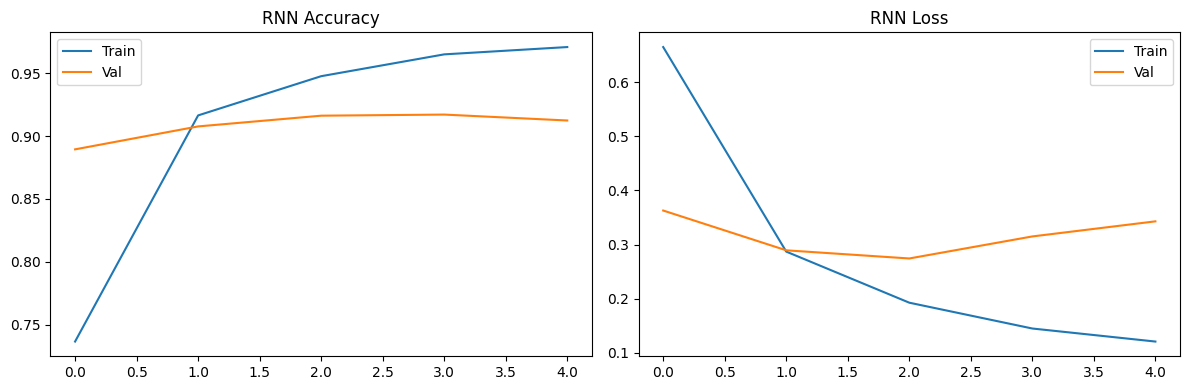

In [27]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_rnn.history['accuracy'],     label='Train'); axes[0].plot(history_rnn.history['val_accuracy'], label='Val'); axes[0].set_title('RNN Accuracy'); axes[0].legend()
axes[1].plot(history_rnn.history['loss'],         label='Train'); axes[1].plot(history_rnn.history['val_loss'],     label='Val'); axes[1].set_title('RNN Loss');     axes[1].legend()
plt.tight_layout(); plt.show()

In [28]:
predictions       = rnn_model.predict(X_test)
predicted_classes = predictions.argmax(axis=1)

reverse_map       = {0: 'positive', 1: 'neutral', 2: 'negative'}
final_predictions = [reverse_map[i] for i in predicted_classes]

results = pd.DataFrame({
    'Tweet':               test['clean_text'],
    'Predicted_Sentiment': final_predictions
})

# Should now show a healthy mix of all 3 classes
print(results['Predicted_Sentiment'].value_counts())
results.head(10)

96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Predicted_Sentiment
positive    1516
neutral     1026
negative     526
Name: count, dtype: int64


,Tweet,Predicted_Sentiment
0,Watch theSocialDilemma then joinMastodon,neutral
1,With the 2019 2020 NBA season officially over ...,neutral
2,if you want to really know about people go tal...,positive
3,Have you watched TheSocialDilemma on Netflix,neutral
4,Highly recommend TheSocialDilemma on,positive
5,Have you ever notce how much time you waste aw...,positive
6,Hey Twitter AIs out there do a healthy thing f...,neutral
7,Just watched TheSocialDilemma appreciate the i...,neutral
8,Anyone watched TheSocialDilemma on Wild Will m...,positive
9,In case anyone was wondering what the 100bn Mo...,positive
